<a href="https://colab.research.google.com/github/Jbrr2021/python-ecommerce-multichannel-analysis/blob/main/Com%C3%A9rcio_eletr%C3%B4nico_multicanal_com_m%C3%A9tricas_comportamentais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Dados em E-commerce Multicanal com Métricas Comportamentais

Este projeto apresenta uma análise exploratória de dados de um dataset de e-commerce multicanal, com foco em comportamento do cliente, receita, churn, engajamento, rentabilidade e valor de longo prazo.

A análise foi desenvolvida com **Python, Pandas, Matplotlib e Google Colab**, com o objetivo de transformar dados em insights de negócio e fortalecer meu portfólio em análise de dados.

## Fonte dos dados

Dataset utilizado: **Multi-Channel E-commerce with Behavioral Metrics**  
Fonte: **Kaggle**  
Autor no Kaggle: **rifatalam3**

## Objetivos da análise

Nesta análise, busquei:

- entender a estrutura e a qualidade do dataset
- validar a consistência temporal dos dados
- identificar canais com melhor desempenho
- comparar receita total e receita média por canal
- analisar churn por segmento e por canal
- observar métricas de engajamento e retenção
- avaliar indicadores como CLV, CLV/CAC e rentabilidade
- construir uma visão mais próxima de um cenário real de negócio

## Sobre o dataset

O dataset reúne informações de clientes, transações e comportamento de compra em um ambiente de e-commerce multicanal.

Entre as variáveis presentes na base, estão:

- perfil do cliente
- renda, escolaridade e estado civil
- produto, quantidade e receita
- canal de marketing e canal da primeira compra
- churn e risco de churn
- métricas de engajamento
- valor do cliente no longo prazo
- indicadores de rentabilidade e aquisição
- datas de aquisição e compra
- variáveis de coorte e retenção

## Carregamento dos dados

Nesta etapa, foi realizado o download do dataset, a leitura do arquivo CSV e a visualização inicial das primeiras linhas da base.

In [ ]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import os

path = kagglehub.dataset_download("rifatalam3/multi-channel-e-commerce-with-behavioral-metrics")
print("Path:", path)
print("Arquivos:", os.listdir(path))

100%|██████████| 4.26M/4.26M [00:00<00:00, 45.7MB/s]

Extracting files...


Path: /root/.cache/kagglehub/datasets/rifatalam3/multi-channel-e-commerce-with-behavioral-metrics/versions/1
Arquivos: ['customer.csv']


In [ ]:
# 1. Carregamento do CSV automaticamente

arquivos = os.listdir(path)
csvs = [arq for arq in arquivos if arq.endswith(".csv")]

print("CSV(s):", csvs)

arquivos_csv = os.path.join(path, csvs[0])
df = pd.read_csv(arquivos_csv)

df.head()

CSV(s): ['customer.csv']


,CustomerID,Customer_Segment,Acquisition_Date,Age,Gender,Job_Category,Annual_Income,Education_Level,Marital_Status,Household_Size,...,Profitability_Score,Age_Group,Revenue_Tier,Seasonal_Factor,Purchase_Month,Purchase_Quarter,Purchase_Year,Days_Since_Acquisition,Acquisition_Month,Cohort_Index
0,C00001,Regular,2023-12-05,49,Female,Manufacturing,53900,Bachelor,Single,2,...,2.04,46-60,Low,1.4,10,4,2024,316,2023-12,10
1,C00002,New,2023-01-26,39,Male,IT,47557,High School,Single,2,...,0.06,31-45,Low,0.9,4,2,2023,89,2023-01,3
2,C00003,Regular,2023-07-01,51,Female,Other,81597,High School,Widowed,2,...,0.66,46-60,Low,0.9,1,1,2023,-156,2023-07,-6
3,C00004,Regular,2023-09-22,64,Male,Finance,100299,Bachelor,Married,3,...,53.40,60+,Premium,1.4,10,4,2023,17,2023-09,1
4,C00005,New,2023-09-15,38,Female,Other,132438,Master,Married,2,...,7.24,31-45,High,1.4,9,3,2023,-7,2023-09,0


## Inspeção inicial dos dados

Antes de aprofundar a análise, foi feita uma inspeção inicial da base para entender sua estrutura geral.

Foram verificados:

- número de linhas e colunas
- tipos de dados
- estatísticas descritivas
- existência de valores ausentes
- organização das variáveis

In [ ]:
# 2. Fazendo a inspeção inicial
print(df.shape)
print(df.columns)
df.info()
print(df.describe())
print(df.isnull().sum())

(50000, 53)
Index(['CustomerID', 'Customer_Segment', 'Acquisition_Date', 'Age', 'Gender',
       'Job_Category', 'Annual_Income', 'Education_Level', 'Marital_Status',
       'Household_Size', 'Product', 'Quantity', 'Unit_Price',
       'Discount_Applied', 'Payment_Method', 'Revenue',
       'Customer_Lifetime_Value', 'Profit_Margin', 'Loyalty_Score',
       'Loyalty_Tier', 'Customer_Satisfaction', 'Purchase_Frequency',
       'Days_Since_Last_Purchase', 'Newsletter_Subscribed', 'Support_Tickets',
       'Email_Open_Rate', 'Social_Media_Engagement', 'Purchase_Date',
       'Purchase_Hour', 'Season', 'Is_Weekend', 'Days_to_Next_Purchase',
       'Churned', 'Churn_Risk_Score', 'Return_Rate', 'Payment_Delay_Days',
       'Customer_Acquisition_Cost', 'Marketing_Channel',
       'First_Purchase_Channel', 'Net_Revenue', 'Revenue_per_Unit',
       'CLV_to_CAC_Ratio', 'Engagement_Score', 'Profitability_Score',
       'Age_Group', 'Revenue_Tier', 'Seasonal_Factor', 'Purchase_Month',
       'Purc

### Principais observações

A base possui um volume robusto de observações e boa variedade de variáveis numéricas e categóricas, permitindo análises em diferentes dimensões do negócio.

Além disso, não foram identificados valores ausentes relevantes nas colunas analisadas, o que favorece a continuidade da exploração dos dados.

## Validação da qualidade dos dados

Antes de seguir para as análises de negócio, foi feita uma checagem da consistência temporal entre a data de aquisição do cliente e a data de compra.

Essa validação é importante porque, em bases reais, inconsistências de datas podem comprometer análises de retenção, jornada do cliente e evolução de valor ao longo do tempo.

In [ ]:
# 3. Organização dos dados
pd.set_option("display.max_columns", None)
df.head()

,CustomerID,Customer_Segment,Acquisition_Date,Age,Gender,Job_Category,Annual_Income,Education_Level,Marital_Status,Household_Size,Product,Quantity,Unit_Price,Discount_Applied,Payment_Method,Revenue,Customer_Lifetime_Value,Profit_Margin,Loyalty_Score,Loyalty_Tier,Customer_Satisfaction,Purchase_Frequency,Days_Since_Last_Purchase,Newsletter_Subscribed,Support_Tickets,Email_Open_Rate,Social_Media_Engagement,Purchase_Date,Purchase_Hour,Season,Is_Weekend,Days_to_Next_Purchase,Churned,Churn_Risk_Score,Return_Rate,Payment_Delay_Days,Customer_Acquisition_Cost,Marketing_Channel,First_Purchase_Channel,Net_Revenue,Revenue_per_Unit,CLV_to_CAC_Ratio,Engagement_Score,Profitability_Score,Age_Group,Revenue_Tier,Seasonal_Factor,Purchase_Month,Purchase_Quarter,Purchase_Year,Days_Since_Acquisition,Acquisition_Month,Cohort_Index
0,C00001,Regular,2023-12-05,49,Female,Manufacturing,53900,Bachelor,Single,2,Product_C,2,40.56,0.449,Bank Transfer,236,6542,0.536,7.7,Bronze,1.0,5,4,1,0,0.072,0.187,2024-10-16,19,Winter,0,58,1,94.4,0.014,8,62,Social,Online,130.036,118.00,105.52,0.476,2.04,46-60,Low,1.4,10,4,2024,316,2023-12,10
1,C00002,New,2023-01-26,39,Male,IT,47557,High School,Single,2,Product_D,3,79.07,0.187,PayPal,100,4803,0.152,12.1,Bronze,1.1,13,2,1,0,0.246,0.033,2023-04-25,14,Summer,1,24,1,92.6,0.012,3,238,Email,App,81.300,33.33,20.18,0.483,0.06,31-45,Low,0.9,4,2,2023,89,2023-01,3
2,C00003,Regular,2023-07-01,51,Female,Other,81597,High School,Widowed,2,Product_E,3,36.91,0.071,Credit Card,207,9149,0.552,16.3,Bronze,1.2,2,19,1,1,0.141,0.319,2023-01-26,14,Summer,0,26,1,90.5,0.034,1,173,Social,Online,192.303,69.00,52.88,0.528,0.66,46-60,Low,0.9,1,1,2023,-156,2023-07,-6
3,C00004,Regular,2023-09-22,64,Male,Finance,100299,Bachelor,Married,3,Product_D,1,85.07,0.344,PayPal,9645,61603,0.454,40.3,Silver,5.0,5,20,1,1,0.585,0.062,2023-10-09,16,Winter,1,5,0,65.6,0.014,26,82,Search,App,6327.120,9645.00,751.26,0.583,53.40,60+,Premium,1.4,10,4,2023,17,2023-09,1
4,C00005,New,2023-09-15,38,Female,Other,132438,Master,Married,2,Product_E,1,64.41,0.283,Bank Transfer,1851,28342,0.348,29.7,Silver,3.0,12,32,0,0,0.165,0.048,2023-09-08,12,Winter,0,7,1,79.5,0.007,2,89,Social,Online,1327.167,1851.00,318.45,0.246,7.24,31-45,High,1.4,9,3,2023,-7,2023-09,0


In [ ]:
#4 . Verificando as datas e inconsistências e exemplos

df["Acquisition_Date"] = pd.to_datetime(df["Acquisition_Date"])
df["Purchase_Date"] = pd.to_datetime(df["Purchase_Date"])

print("Compras antes da aquisião:")
print((df["Purchase_Date"] < df["Acquisition_Date"]).sum())

print("\nDays_Since_Acquisition negativos:")
print((df["Days_Since_Acquisition"] < 0).sum())

print("\nCohort_Index_Acquisition:")
print((df["Cohort_Index"] < 0).sum())

df[df["Purchase_Date"] < df["Acquisition_Date"]][[
    "CustomerID", "Acquisition_Date", "Purchase_Date",
    "Days_Since_Acquisition", "Cohort_Index"
]].head(10)

Compras antes da aquisião:
12495

Days_Since_Acquisition negativos:
12495

Cohort_Index_Acquisition:
11479


,CustomerID,Acquisition_Date,Purchase_Date,Days_Since_Acquisition,Cohort_Index
2,C00003,2023-07-01,2023-01-26,-156,-6
4,C00005,2023-09-15,2023-09-08,-7,0
6,C00007,2023-10-01,2023-05-23,-131,-5
10,C00011,2023-06-19,2023-03-31,-80,-3
13,C00014,2023-03-11,2023-02-02,-37,-1
14,C00015,2023-10-29,2023-01-31,-271,-9
20,C00021,2023-05-20,2023-01-28,-112,-4
22,C00023,2023-09-18,2023-07-23,-57,-2
31,C00032,2023-01-08,2023-01-07,-1,0
37,C00038,2023-11-08,2023-06-09,-152,-5


### Interpretação

Foi identificado um volume relevante de inconsistências temporais, com registros de compras anteriores à data de aquisição do cliente.

Por esse motivo, foi criada uma **base limpa**, considerando apenas os casos em que a data de compra é igual ou posterior à data de aquisição. Essa decisão torna as análises seguintes mais confiáveis.

## Receita líquida por canal de marketing

Nesta etapa, foi analisada a receita líquida total gerada por cada canal de marketing.

Essa visão ajuda a entender quais canais contribuem mais para o faturamento total da operação.

In [ ]:
# 5. Receitas por canal

df.groupby("Marketing_Channel")["Net_Revenue"].sum().sort_values(ascending=False)

,Net_Revenue
Marketing_Channel,
Search,1.851169e+07
Social,1.554103e+07
Email,1.248588e+07
Referral,9.023375e+06
Direct,6.224961e+06


### Interpretação

Os resultados indicaram que o canal **Search** lidera em receita líquida total, seguido por **Social** e **Email**.

Isso sugere que o canal de busca possui maior relevância em escala de negócio, provavelmente por combinar maior volume de clientes com boa geração de receita.

## Volume de clientes por canal

Além da receita total, também foi analisada a quantidade de clientes associada a cada canal de marketing.

Essa leitura ajuda a separar dois efeitos:

- canais que performam bem por volume
- canais que performam bem por maior valor por cliente

In [ ]:
# 6. Clientes por canal

df["Marketing_Channel"].value_counts()

,count
Marketing_Channel,
Search,15034
Social,12456
Email,10035
Referral,7427
Direct,5048


### Interpretação

O canal **Search** também apareceu como líder em número de clientes, reforçando sua importância em escala.

Isso ajuda a explicar por que ele lidera a receita total: seu desempenho parece ser impulsionado principalmente pelo volume.

## Receita líquida por produto

Nesta etapa, foi observada a contribuição de cada produto para a receita líquida total.

Esse tipo de análise ajuda a identificar produtos com maior relevância financeira e possíveis focos de estratégia comercial.

In [ ]:
# 7. Receita por produto

df.groupby("Product")["Net_Revenue"].sum().sort_values(ascending=False)

,Net_Revenue
Product,
Product_E,1.302075e+07
Product_B,1.257259e+07
Product_C,1.230741e+07
Product_A,1.208145e+07
Product_D,1.180473e+07


### Interpretação

Os produtos apresentaram desempenho relativamente equilibrado, com destaque para **Product_E** como líder de receita.

Esse resultado sugere que o negócio não depende exclusivamente de um único produto, o que pode ser positivo do ponto de vista de diversificação.

## Taxa de churn geral

A análise de churn foi incluída para observar o nível de perda de clientes na base.

Essa métrica é importante para entender a sustentabilidade da operação e o risco de saída dos clientes ao longo do tempo.

In [ ]:
# 8. Taxa de churn geral
df["Churned"].mean()

np.float64(0.76568)

### Interpretação

A taxa geral de churn encontrada foi bastante alta.

Esse resultado pode indicar um cenário de forte rotatividade de clientes ou, alternativamente, refletir a forma como a variável foi construída no dataset. Em qualquer caso, a métrica merece atenção por seu impacto direto sobre retenção e valor do cliente.

## Taxa de churn por segmento

Nesta etapa, a taxa de churn foi comparada entre os segmentos **New**, **Regular** e **VIP**.

O objetivo foi verificar se grupos de clientes apresentam diferenças relevantes de retenção.

In [ ]:
# 9. Taxa Churn por segmento

df.groupby("Customer_Segment")["Churned"].mean().sort_values(ascending=False)

,Churned
Customer_Segment,
New,0.769500
VIP,0.765402
Regular,0.763535


### Interpretação

As diferenças de churn entre os segmentos foram pequenas.

Isso sugere que, nesta base, o segmento do cliente não foi um fator fortemente discriminante para explicar a saída, pelo menos de forma isolada.

## Taxa de churn por canal

Também foi feita a comparação do churn por canal de marketing, para verificar se alguns canais atraem clientes com maior permanência do que outros.

In [ ]:
# 10. Churn por canal

df.groupby("Marketing_Channel")["Churned"].mean().sort_values(ascending=False)

,Churned
Marketing_Channel,
Search,0.766995
Direct,0.766838
Social,0.765735
Email,0.765222
Referral,0.762758


### Interpretação

As diferenças entre os canais foram discretas, o que indica que o canal de aquisição, sozinho, não explica grandes variações na taxa de churn.

Mesmo assim, pequenas diferenças podem ser úteis quando combinadas com outras métricas, como CLV e CAC.

## Receita média por canal

Depois de analisar a receita total, foi calculada a receita média por cliente em cada canal.

Essa etapa é importante para diferenciar **escala** de **eficiência**.

In [ ]:
# 11. Top canias por lucro líquido

df.groupby("Marketing_Channel")["Net_Revenue"].mean().sort_values(ascending=False)

,Net_Revenue
Marketing_Channel,
Social,1247.674488
Email,1244.233279
Direct,1233.153961
Search,1231.321780
Referral,1214.942083


### Interpretação

A receita média por canal ficou bastante próxima entre os diferentes canais.

Isso indica que a grande diferença de receita total observada anteriormente parece estar mais ligada ao volume de clientes do que a uma forte diferença de ticket médio.

## Customer Lifetime Value por segmento

O **Customer Lifetime Value (CLV)** representa o valor de longo prazo gerado por um cliente.

A comparação entre segmentos ajuda a entender quais grupos têm maior potencial estratégico para retenção e rentabilidade.

In [ ]:
# 13. CLV por segmento

df.groupby("Customer_Segment")["Customer_Lifetime_Value"].mean().sort_values(ascending=False)

,Customer_Lifetime_Value
Customer_Segment,
VIP,22302.379290
Regular,22085.826256
New,21930.144492


### Interpretação

O segmento **VIP** apresentou o maior CLV médio, seguido por **Regular** e **New**.

Esse resultado é coerente com a expectativa de que clientes mais valiosos gerem maior retorno financeiro ao longo do relacionamento com a empresa.

## Profitability Score por faixa de receita

A análise por **Revenue_Tier** ajuda a verificar se faixas de receita mais altas realmente se convertem em maior rentabilidade.

In [ ]:
# 14. Profitability por tier

df.groupby("Revenue_Tier")["Profitability_Score"].mean().sort_values(ascending=False)

,Profitability_Score
Revenue_Tier,
Premium,19.872162
High,6.995104
Medium,3.358058
Low,1.185135


### Interpretação

A faixa **Premium** apresentou a maior pontuação de rentabilidade, com ampla diferença em relação às demais.

Esse resultado reforça a importância de identificar e reter clientes de maior valor, já que eles concentram parcela relevante do retorno financeiro.

## Engajamento por canal

O engajamento médio foi comparado entre os canais para avaliar se alguns deles atraem clientes mais envolvidos com a marca.

In [ ]:
# 15. Engajamento por canal

df.groupby("Marketing_Channel")["Engagement_Score"].mean().sort_values(ascending=False)

,Engagement_Score
Marketing_Channel,
Direct,0.495647
Email,0.495514
Search,0.494983
Referral,0.494142
Social,0.490823


### Interpretação

O canal **Direct** apresentou o maior engajamento médio, embora a diferença entre os canais tenha sido pequena.

Isso sugere que o canal direto pode atrair clientes ligeiramente mais conectados com a marca.

## Newsletter e churn

Foi analisada a relação entre inscrição em newsletter e taxa de churn, com o objetivo de verificar se esse tipo de contato pode estar associado a melhor retenção.

In [ ]:
# 16. Newsletter X Churn

df.groupby("Newsletter_Subscribed")["Churned"].mean()

,Churned
Newsletter_Subscribed,
0,0.768786
1,0.764014


### Interpretação

Clientes inscritos na newsletter apresentaram churn ligeiramente menor.

Embora a diferença não seja grande, esse sinal sugere que ações de relacionamento contínuo podem contribuir positivamente para retenção.

## Email open rate e churn

Também foi comparada a taxa média de abertura de e-mail entre clientes churnados e não churnados.

In [ ]:
# 17. Email open rate X Churn

df.groupby("Churned")["Email_Open_Rate"].mean()

,Email_Open_Rate
Churned,
0,0.399107
1,0.399175


## Receita líquida por canal de marketing

O gráfico a seguir apresenta a receita líquida total gerada por cada canal de marketing.

Essa análise ajuda a identificar quais canais têm maior contribuição para o faturamento total da operação.

### Interpretação

O canal **Search** apresentou a maior receita líquida total, seguido por **Social** e **Email**.

Esse resultado indica que o canal de busca possui forte relevância para a geração de receita, provavelmente por combinar maior volume de clientes com bom desempenho comercial.

Já os canais **Referral** e **Direct** aparecem com menor participação relativa no faturamento total.

### Interpretação

A taxa média de abertura de e-mail apresentou pouca diferença entre os grupos.

Isso indica que, isoladamente, essa métrica não parece ser suficiente para explicar churn nesta base.

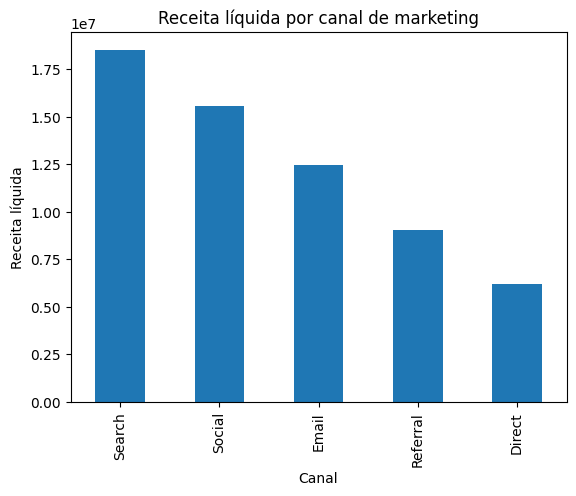

In [ ]:
# 18. Gráfico Receita por canal.

receita_canal = df.groupby("Marketing_Channel")["Net_Revenue"].sum().sort_values(ascending=False)

receita_canal.plot(kind="bar")
plt.title("Receita líquida por canal de marketing")
plt.xlabel("Canal")
plt.ylabel("Receita líquida")
plt.show()


## Taxa de churn por segmento

Nesta etapa, a taxa média de churn foi comparada entre os segmentos de clientes.

O objetivo foi verificar se grupos como **New**, **Regular** e **VIP** apresentam diferenças relevantes de retenção.

### Interpretação

As taxas de churn entre os segmentos foram muito próximas.

Isso sugere que, nesta base, o segmento do cliente **não foi um fator fortemente discriminante** para explicar a saída de clientes.

Assim, outras variáveis podem ter maior poder explicativo do que a segmentação isolada.

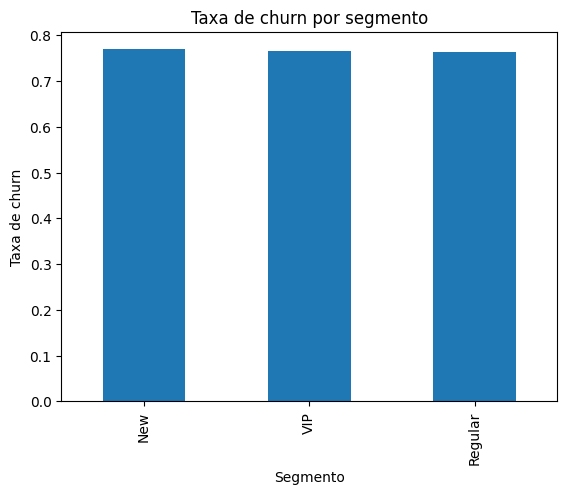

In [ ]:
# 19. Gráfico Chur por segmento

churn_segmento = df.groupby("Customer_Segment")["Churned"].mean().sort_values(ascending=False)

churn_segmento.plot(kind="bar")
plt.title("Taxa de churn por segmento")
plt.xlabel("Segmento")
plt.ylabel("Taxa de churn")
plt.show()

## Receita líquida por produto

O gráfico abaixo mostra a contribuição de cada produto para a receita líquida total.

Essa leitura permite identificar quais produtos geram maior retorno financeiro para o negócio.

### Interpretação

Os produtos apresentaram desempenho relativamente equilibrado, com destaque para **Product_E**, que liderou a receita líquida.

Esse resultado sugere que o negócio não depende exclusivamente de um único produto, o que pode ser positivo do ponto de vista de diversificação.

Ainda assim, o melhor desempenho do Product_E pode indicar uma oportunidade de aprofundar análises sobre preço, volume e margem desse item.

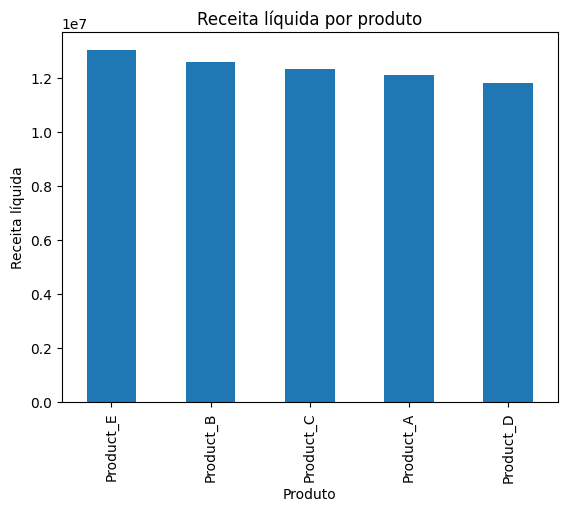

In [ ]:
# 20. Gráfico Receita por produto

receita_produto = df.groupby("Product")["Net_Revenue"].sum().sort_values(ascending=False)

receita_produto.plot(kind="bar")
plt.title("Receita líquida por produto")
plt.xlabel("Produto")
plt.ylabel("Receita líquida")
plt.show()

## Distribuição da idade dos clientes

A distribuição da idade foi analisada para entender o perfil etário predominante na base.

Essa visualização ajuda a identificar concentrações de clientes em determinadas faixas etárias e possíveis padrões de público.

### Interpretação

A distribuição mostra maior concentração de clientes em faixas adultas, com predominância aproximada entre **30 e 55 anos**.

As idades mais elevadas aparecem em menor frequência, indicando que a base é formada majoritariamente por clientes em idade economicamente ativa.

Esse perfil pode ser útil para orientar futuras análises de segmentação e comportamento de compra.

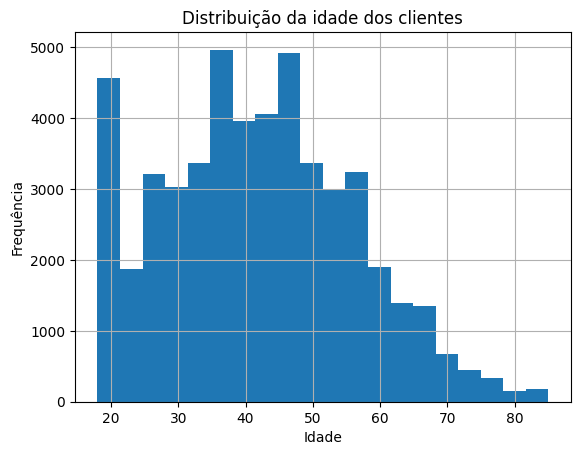

In [ ]:
# 21 Distribuição da idade

df["Age"].hist(bins=20)
plt.title("Distribuição da idade dos clientes")
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.show()

## Validação da qualidade dos dados

Antes de aprofundar análises temporais e de retenção, foi realizada uma verificação de consistência entre a **data de aquisição** e a **data de compra**.

O objetivo dessa etapa foi identificar registros em que a compra ocorreu antes da aquisição do cliente, o que representa uma inconsistência lógica para análises de jornada.

### Interpretação

Foi identificado um volume relevante de registros inconsistentes, com compras registradas antes da data de aquisição.

Por esse motivo, foi criada uma **base limpa**, contendo apenas observações em que a data de compra é igual ou posterior à data de aquisição.

Essa decisão aumenta a confiabilidade das análises temporais, especialmente as relacionadas a retenção, coorte, CLV e evolução do cliente ao longo do tempo.

In [ ]:
# 22. Validação da qualidade dos dados

df_clean = df[df["Purchase_Date"] >= df["Acquisition_Date"]].copy()
print(df_clean.shape)

(37505, 53)


## Validação da qualidade dos dados

Antes de aprofundar análises temporais e de retenção, foi realizada uma verificação de consistência entre a **data de aquisição** e a **data de compra**.

O objetivo dessa etapa foi identificar registros em que a compra ocorreu antes da aquisição do cliente, o que representa uma inconsistência lógica para análises de jornada.

### Interpretação

Foi identificado um volume relevante de registros inconsistentes, com compras registradas antes da data de aquisição.

Por esse motivo, foi criada uma **base limpa**, contendo apenas observações em que a data de compra é igual ou posterior à data de aquisição.

Essa decisão aumenta a confiabilidade das análises temporais, especialmente as relacionadas a retenção, coorte, CLV e evolução do cliente ao longo do tempo.

In [ ]:
print("""
Conclusão parcial:

A análise inicial mostrou que o canal Search lidera em receita total e volume de clientes,
enquanto Social apresenta a maior receita média por cliente. Direct, apesar de menor escala,
teve o maior engajamento médio.

Os produtos apresentaram receita relativamente equilibrada, com destaque para Product_E.
Já a taxa de churn se mostrou muito alta no conjunto de dados e com pouca diferença entre
segmentos e canais, o que pode indicar uma variável pouco discriminativa ou fortemente sintética.

Também foi identificado um ponto importante de qualidade dos dados: uma parcela relevante da
base apresenta compras anteriores à data de aquisição, o que exige o uso de uma versão limpa
para análises temporais e de retenção mais confiáveis.
""")


Conclusão parcial:

A análise inicial mostrou que o canal Search lidera em receita total e volume de clientes,
enquanto Social apresenta a maior receita média por cliente. Direct, apesar de menor escala,
teve o maior engajamento médio.

Os produtos apresentaram receita relativamente equilibrada, com destaque para Product_E.
Já a taxa de churn se mostrou muito alta no conjunto de dados e com pouca diferença entre
segmentos e canais, o que pode indicar uma variável pouco discriminativa ou fortemente sintética.

Também foi identificado um ponto importante de qualidade dos dados: uma parcela relevante da
base apresenta compras anteriores à data de aquisição, o que exige o uso de uma versão limpa
para análises temporais e de retenção mais confiáveis.



## Conclusão parcial

A análise inicial mostrou que o canal **Search** lidera em receita total e volume de clientes, enquanto **Social** apresentou a maior receita média por cliente.

Em relação aos produtos, houve distribuição relativamente equilibrada da receita, com destaque para **Product_E**.

Por outro lado, as análises de churn mostraram pouca diferença entre segmentos, canais, newsletter e taxa de abertura de e-mail, sugerindo que a variável de churn pode ter comportamento pouco discriminante nesta base.

Além disso, a verificação da qualidade dos dados revelou inconsistências temporais relevantes, tornando necessária a construção de uma base limpa para análises mais confiáveis.

In [ ]:
# 23. Repetir os principais resultados com a base limpa.

df_clean.groupby("Marketing_Channel")["Net_Revenue"].sum().sort_values(ascending=False)
df_clean.groupby("Customer_Segment")["Churned"].mean().sort_values(ascending=False)
df_clean.groupby("Product")["Net_Revenue"].sum().sort_values(ascending=False)

,Net_Revenue
Product,
Product_E,9868379.589
Product_B,9284552.208
Product_C,9207033.345
Product_A,9094649.526
Product_D,8914580.423


# Reanálise com base limpa

Após a identificação de inconsistências temporais, foi criada uma versão limpa da base de dados.

A partir deste ponto, as análises passam a considerar apenas registros consistentes, isto é, casos em que a data de compra é igual ou posterior à data de aquisição do cliente.

Essa etapa tem como objetivo gerar resultados mais confiáveis para métricas de valor, aquisição e retenção.

In [ ]:
# 24. CVL por canal
df_clean.groupby("Marketing_Channel")["Customer_Lifetime_Value"].mean().sort_values(ascending=False)

,Customer_Lifetime_Value
Marketing_Channel,
Referral,22354.871580
Search,22116.681450
Social,21995.709404
Direct,21843.828579
Email,21772.753722


## CLV médio por canal

Nesta etapa, foi calculado o **Customer Lifetime Value (CLV)** médio por canal de marketing.

O objetivo é identificar quais canais atraem clientes com maior valor ao longo do relacionamento com a empresa.

### Interpretação

Os resultados mostraram que **Referral** apresentou o maior CLV médio, seguido de **Search**, **Social**, **Direct** e **Email**.

Isso sugere que, embora alguns canais não liderem em volume ou receita total, podem trazer clientes com maior valor de longo prazo.

Essa análise é importante para decisões estratégicas de aquisição e alocação de investimento em marketing.

In [ ]:
# 25. Relação CLV x CAC por canal

df_clean.groupby("Marketing_Channel")["CLV_to_CAC_Ratio"].mean().sort_values(ascending=False)

,CLV_to_CAC_Ratio
Marketing_Channel,
Referral,282.432016
Search,281.453452
Social,281.131533
Email,274.992304
Direct,272.846713


## Relação CLV/CAC por canal

A relação entre **Customer Lifetime Value (CLV)** e **Customer Acquisition Cost (CAC)** foi analisada para avaliar a eficiência econômica de cada canal de marketing.

Essa métrica ajuda a entender não apenas quais canais geram clientes valiosos, mas também quais fazem isso com melhor equilíbrio entre retorno e custo de aquisição.

### Interpretação

O canal **Referral** apresentou a melhor relação CLV/CAC, seguido de **Search** e **Social**.

Isso indica que esses canais tendem a ser mais eficientes financeiramente, combinando bom valor gerado com custo de aquisição relativamente bem compensado.

Já **Email** e **Direct** apresentaram valores um pouco menores, embora ainda próximos dos demais.

## Análise de coorte e retenção

A análise de coorte foi utilizada para acompanhar a permanência dos clientes ao longo do tempo, agrupando-os pelo mês de aquisição.

Essa abordagem permite observar como diferentes grupos de clientes evoluem após a entrada na base e identificar padrões de retenção ao longo dos períodos.

### Importante

Para que a retenção seja corretamente calculada, o número de clientes ativos em cada período deve ser dividido pelo **tamanho original da coorte**, e não apenas pela atividade do mês zero observada na tabela dinâmica.

### Interpretação

A análise de coorte permite comparar o comportamento das diferentes safras de clientes adquiridos em cada mês.

Com a base limpa, essa visualização se torna mais confiável, pois reduz o efeito de inconsistências temporais que poderiam distorcer a permanência dos clientes ao longo do tempo.

In [ ]:
# 26 corrigido - Coorte / Retenção

# total de clientes adquiridos em cada mês
cohort_size = df_clean.groupby("Acquisition_Month")["CustomerID"].nunique()

# clientes ativos por mês da coorte
cohort_data = df_clean[df_clean["Cohort_Index"] >= 0].groupby(
    ["Acquisition_Month", "Cohort_Index"]
)["CustomerID"].nunique().reset_index()

# tabela em formato pivot
cohort_pivot = cohort_data.pivot(
    index="Acquisition_Month",
    columns="Cohort_Index",
    values="CustomerID"
)

# retenção correta
cohort_retention = cohort_pivot.divide(cohort_size, axis=0)

print("Tamanho das coortes:")
print(cohort_size.head())

print("\nTabela de atividade por coorte:")
print(cohort_pivot.head())

print("\nRetenção corrigida:")
print(cohort_retention.head())


Tamanho das coortes:
Acquisition_Month
2023-01    4146
2023-02    3657
2023-03    3743
2023-04    3524
2023-05    3471
Name: CustomerID, dtype: int64

Tabela de atividade por coorte:
Cohort_Index          0      1      2      3      4      5      6      7   \
Acquisition_Month                                                           
2023-01            105.0  169.0  171.0  173.0  174.0  162.0  164.0  188.0   
2023-02             83.0  167.0  150.0  155.0  158.0  157.0  165.0  162.0   
2023-03             83.0  159.0  174.0  171.0  190.0  192.0  169.0  149.0   
2023-04             96.0  172.0  171.0  186.0  182.0  159.0  173.0  173.0   
2023-05             86.0  191.0  183.0  171.0  184.0  155.0  172.0  174.0   

Cohort_Index          8      9      10     11     12     13     14     15  \
Acquisition_Month                                                           
2023-01            174.0  178.0  193.0  179.0  197.0  166.0  146.0  174.0   
2023-02            186.0  148.0  167.0  166.0 

## Receita média por canal

Nesta etapa, foi analisada a **receita média líquida por cliente em cada canal de marketing**, utilizando a base limpa.

Essa métrica é importante porque complementa a análise de receita total. Enquanto a receita total mostra escala, a receita média ajuda a entender a **eficiência de monetização por cliente** em cada canal.

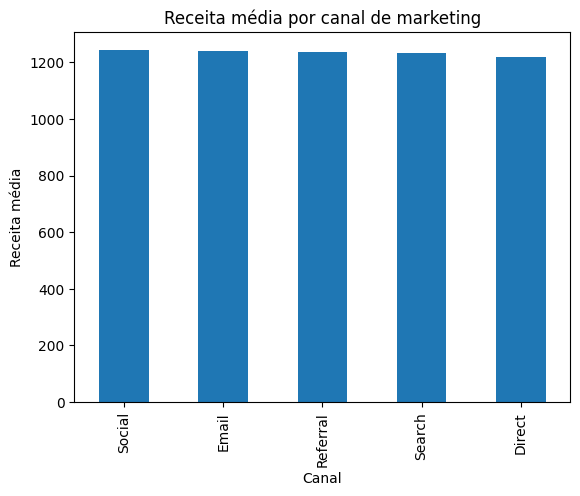

In [ ]:
# 27.Gráfico Receita média por canal

ticket_canal = df_clean.groupby("Marketing_Channel")["Net_Revenue"].mean().sort_values(ascending=False)

ticket_canal.plot(kind="bar")
plt.title("Receita média por canal de marketing")
plt.xlabel("Canal")
plt.ylabel("Receita média")
plt.show()

### Interpretação

Os resultados indicam que a **receita média por canal ficou bastante próxima entre os canais analisados**.

Isso sugere que a diferença observada anteriormente na receita total está mais associada ao **volume de clientes trazidos por cada canal** do que a diferenças muito grandes de ticket médio.

Em termos práticos, canais como **Social, Email e Referral** apresentaram desempenho semelhante ao de **Search**, mostrando que podem ser competitivos quando avaliados por valor médio gerado por cliente.

## CLV médio por canal

Em seguida, foi analisado o **Customer Lifetime Value (CLV) médio por canal**, com o objetivo de verificar quais canais atraem clientes com maior valor potencial ao longo do relacionamento com a empresa.

O CLV é uma métrica estratégica porque amplia a visão além da compra imediata, permitindo avaliar o valor de longo prazo gerado por cada canal de aquisição.

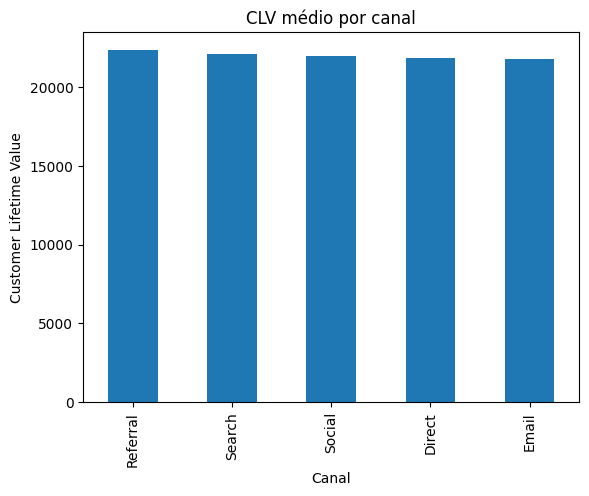

In [ ]:
# 28. Gráfico CLV médio por canal

clv_canal = df_clean.groupby("Marketing_Channel")["Customer_Lifetime_Value"].mean().sort_values(ascending=False)

clv_canal.plot(kind="bar")
plt.title("CLV médio por canal")
plt.xlabel("Canal")
plt.ylabel("Customer Lifetime Value")
plt.show()

### Interpretação

Os resultados mostram que os canais apresentaram **CLV médio relativamente próximo**, com leve destaque para **Referral** e **Search**.

Isso pode indicar que esses canais não apenas geram clientes, mas também atraem consumidores com potencial de maior valor ao longo do tempo.

Mesmo com diferenças discretas, essa análise é útil para orientar decisões de investimento em canais que combinam aquisição com geração de valor no longo prazo.

## Relação CLV/CAC por canal

Por fim, foi analisada a **relação entre CLV e CAC por canal**, um dos indicadores mais importantes para avaliar a eficiência econômica da aquisição de clientes.

Essa métrica compara o valor gerado pelo cliente ao longo do tempo com o custo necessário para adquiri-lo. Em geral, quanto maior essa relação, mais eficiente tende a ser o canal.

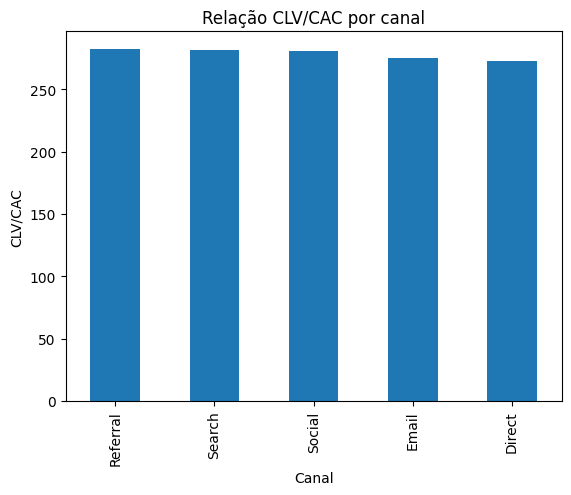

In [ ]:
# 29. Gráfico CLV/CAC por canal.

ratio_canal = df_clean.groupby("Marketing_Channel")["CLV_to_CAC_Ratio"].mean().sort_values(ascending=False)

ratio_canal.plot(kind="bar")
plt.title("Relação CLV/CAC por canal")
plt.xlabel("Canal")
plt.ylabel("CLV/CAC")
plt.show()

### Interpretação

Os resultados indicam que a **relação CLV/CAC ficou alta e relativamente equilibrada entre os canais**, com pequena vantagem para **Referral**, **Search** e **Social**.

Isso sugere que, na base limpa, os canais analisados apresentam boa eficiência de aquisição, sem grandes diferenças estruturais entre si.

Do ponto de vista estratégico, esses resultados reforçam que a escolha do canal pode depender não apenas do custo de aquisição, mas também do potencial de geração de valor no longo prazo.

## Conclusão final

Com base na análise exploratória e na reavaliação com a base limpa, foi possível identificar alguns pontos principais:

- o canal **Search** se destacou em escala, liderando a receita total e o volume de clientes;
- a **receita média por canal** apresentou pouca variação, indicando que a diferença de performance está mais ligada ao volume do que ao ticket médio;
- o **CLV médio** e a **relação CLV/CAC** mostraram resultados equilibrados entre os canais, com leve vantagem para **Referral** e **Search**;
- as análises de churn revelaram diferenças pequenas entre segmentos e canais, sugerindo que outras variáveis podem ser mais relevantes para explicar retenção;
- a etapa de limpeza dos dados foi essencial para garantir maior confiabilidade às análises temporais e estratégicas.

De forma geral, o dataset permitiu observar um cenário em que alguns canais se destacam mais por escala, enquanto outros apresentam desempenho competitivo quando analisados por eficiência e valor de longo prazo.